# Akomolafe Nathaniel Iyanuoluwa Data Science Sales Prediction Using Python
**Objective:** Predict product sales from TV, Radio, and Newspaper advertising spend using regression.

**Dataset:** Classic `Advertising.csv` dataset (200 rows: TV, Radio, Newspaper, Sales).

## Loading the Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

Sale_Prediction = pd.read_csv(r"C:\Users\ThePhantomTrader\OneDrive\Desktop\Oasis Infobyte\TASK 5\advertising.csv")
Sale_Prediction = Sale_Prediction.drop(columns=[c for c in Sale_Prediction.columns if c.lower().startswith('unnamed')])
Sale_Prediction.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


## Exploratory Data Analysis (EDA)

In [2]:
dataset_summary = pd.DataFrame({
    "Metric": ["Rows", "Columns", "Missing Values"],
    "Value": [
        Sale_Prediction.shape[0],
        Sale_Prediction.shape[1],
        Sale_Prediction.isnull().sum().sum()
    ]
})

dataset_summary


,Metric,Value
0,Rows,200
1,Columns,4
2,Missing Values,0


In [3]:
Sale_Prediction.isnull().sum().to_frame("Missing Values")

,Missing Values
TV,0
Radio,0
Newspaper,0
Sales,0


In [4]:
Sale_Prediction.describe().T

,count,mean,std,min,25%,50%,75%,max
TV,200.0,147.0425,85.854236,0.7,74.375,149.75,218.825,296.4
Radio,200.0,23.2640,14.846809,0.0,9.975,22.90,36.525,49.6
Newspaper,200.0,30.5540,21.778621,0.3,12.750,25.75,45.100,114.0
Sales,200.0,15.1305,5.283892,1.6,11.000,16.00,19.050,27.0


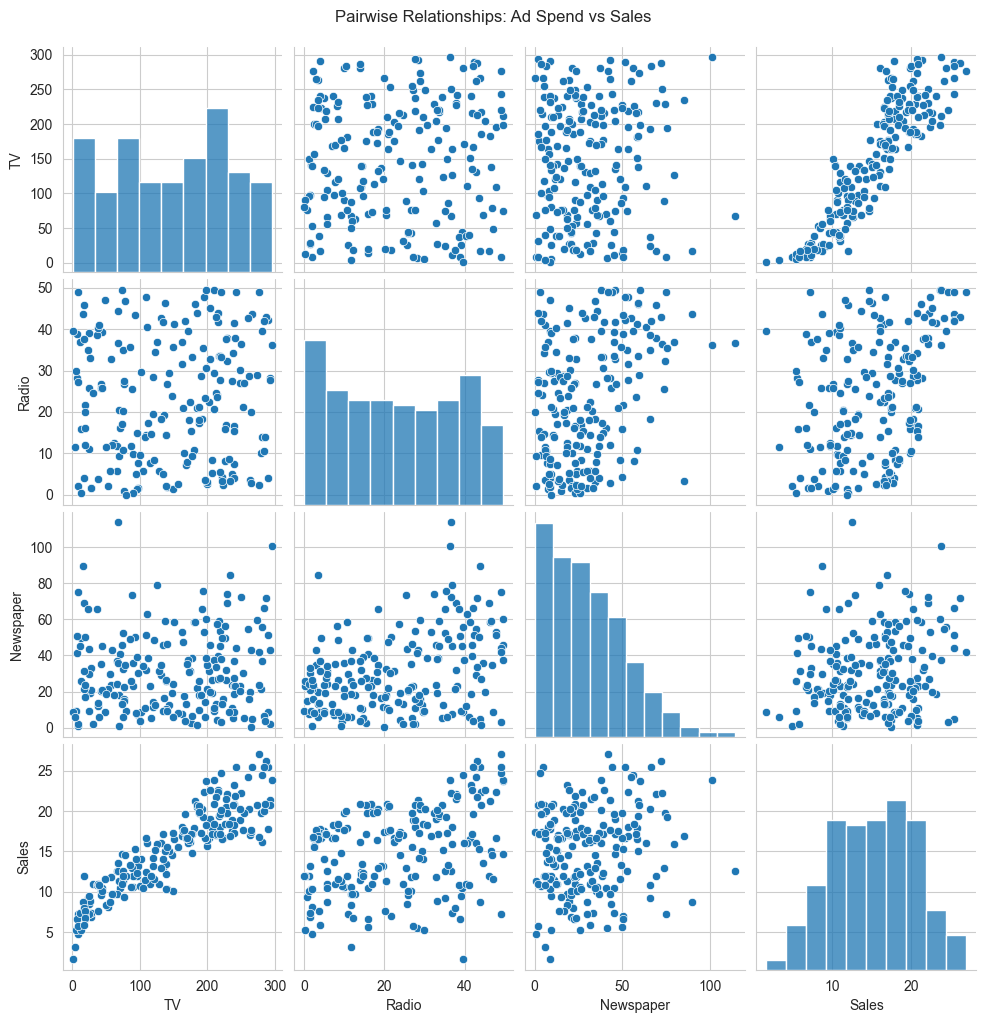

In [5]:
sns.pairplot(Sale_Prediction)
plt.suptitle('Pairwise Relationships: Ad Spend vs Sales', y=1.02)
plt.savefig(r"C:\Users\ThePhantomTrader\OneDrive\Desktop\Oasis Infobyte\TASK 5\advertising_pairplot.png",
            dpi=300,
            bbox_inches='tight')
plt.show()

##  Individual Scatter Plots

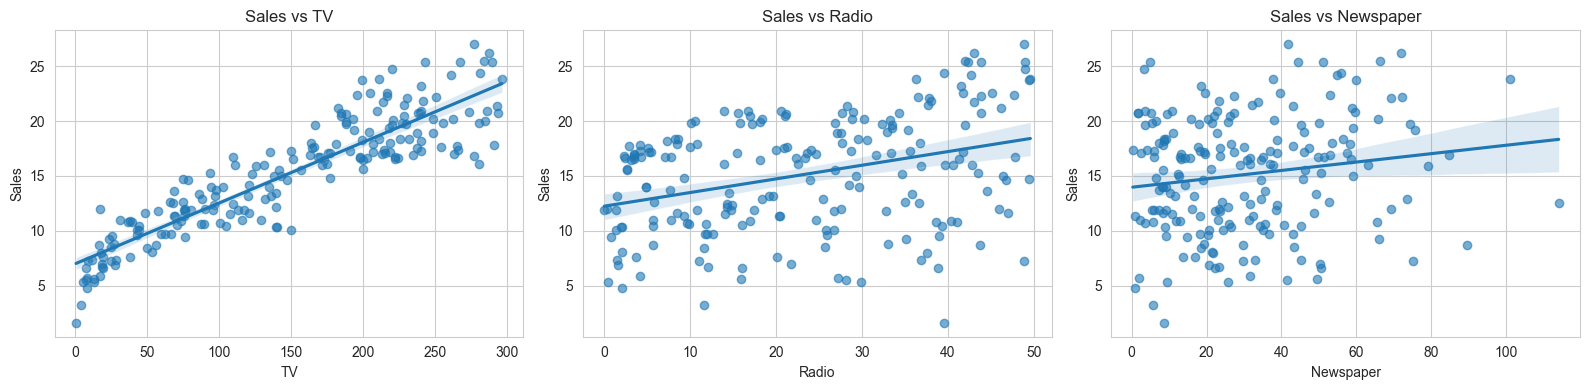

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ['TV', 'Radio', 'Newspaper']):
    sns.regplot(data=Sale_Prediction, x=col, y='Sales', ax=ax, scatter_kws={'alpha':0.6})
    ax.set_title(f'Sales vs {col}')
plt.tight_layout()
plt.savefig(r"C:\Users\ThePhantomTrader\OneDrive\Desktop\Oasis Infobyte\TASK 5\advertising_individual_plots.png",
            dpi=300,
            bbox_inches='tight')
plt.show()

**Observation:** TV spend shows the strongest, most linear relationship with Sales. Radio shows a moderate positive relationship. Newspaper shows a weak, noisy relationship with Sales.

## Correlation Matrix

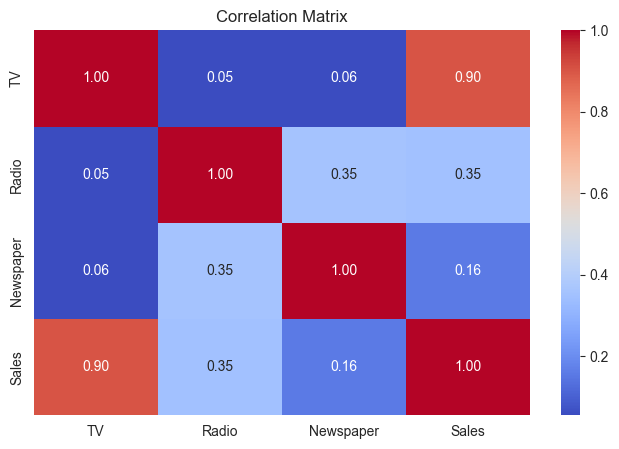

In [7]:
corr = Sale_Prediction.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.savefig(r"C:\Users\ThePhantomTrader\OneDrive\Desktop\Oasis Infobyte\TASK 5\advertising_correlation_matrix.png",
            dpi=300,
            bbox_inches='tight')
plt.show()

## Train/Test Split

In [8]:
X = Sale_Prediction[['TV', 'Radio', 'Newspaper']]
y = Sale_Prediction['Sales']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

split_summary = pd.DataFrame({
    "Dataset": ["Training Set", "Testing Set"],
    "Rows": [X_train.shape[0], X_test.shape[0]],
    "Columns": [X_train.shape[1], X_test.shape[1]]
})

split_summary

,Dataset,Rows,Columns
0,Training Set,160,3
1,Testing Set,40,3


## Linear Regression (Baseline)

In [9]:
lr = LinearRegression()

lr.fit(X_train, y_train)

lr_preds = lr.predict(X_test)

lr_mae = mean_absolute_error(y_test, lr_preds)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_preds))
lr_r2 = r2_score(y_test, lr_preds)

performance_df = pd.DataFrame({
    "Model": ["Linear Regression"],
    "MAE": [lr_mae],
    "RMSE": [lr_rmse],
    "R² Score": [lr_r2]
}).round(3)

performance_df

,Model,MAE,RMSE,R² Score
0,Linear Regression,1.275,1.705,0.906


In [10]:
coeffs = (
    pd.DataFrame({
        "Feature": X.columns,
        "Coefficient": lr.coef_
    })
    .sort_values(by="Coefficient", ascending=False)
    .reset_index(drop=True)
)
coeffs["Impact"] = coeffs["Coefficient"].apply(
    lambda x: "Positive" if x > 0 else "Negative"
)

coeffs


,Feature,Coefficient,Impact
0,Radio,0.100945,Positive
1,TV,0.054509,Positive
2,Newspaper,0.004337,Positive


## Random Forest Regressor

In [11]:
rf = RandomForestRegressor(n_estimators=200, random_state=42)

rf.fit(X_train, y_train)

rf_preds = rf.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_preds)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
rf_r2 = r2_score(y_test, rf_preds)

rf_performance = pd.DataFrame({
    "Model": ["Random Forest Regressor"],
    "MAE": [rf_mae],
    "RMSE": [rf_rmse],
    "R² Score": [rf_r2]
}).round(3)

rf_performance

,Model,MAE,RMSE,R² Score
0,Random Forest Regressor,0.914,1.183,0.955


## Model Comparison

In [12]:
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE': [lr_mae, rf_mae],
    'RMSE': [lr_rmse, rf_rmse],
    'R2': [lr_r2, rf_r2]
})
comparison

,Model,MAE,RMSE,R2
0,Linear Regression,1.274826,1.705215,0.905901
1,Random Forest,0.914075,1.182847,0.954722


In [13]:
best_model_name = comparison.loc[comparison['R2'].idxmax(), 'Model']

best_model = pd.DataFrame({
    "Best Model": [best_model_name]
})

best_preds = rf_preds if best_model_name == 'Random Forest' else lr_preds
best_model

,Best Model
0,Random Forest


## Residual Plot (Best Model)

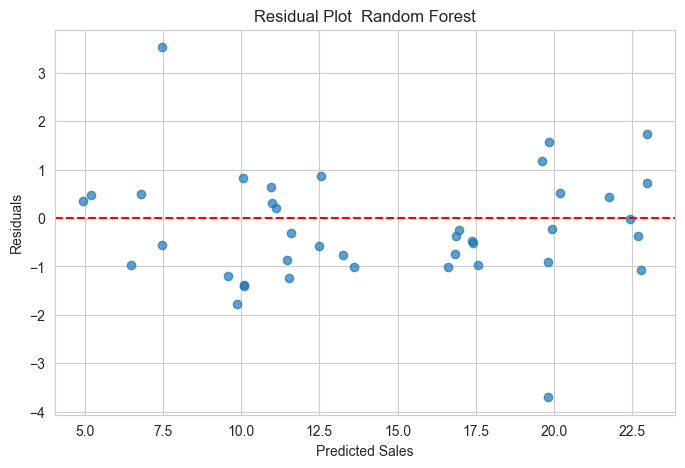

In [14]:
residuals = y_test.values - best_preds
plt.figure(figsize=(8,5))
plt.scatter(best_preds, residuals, alpha=0.7)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Sales')
plt.ylabel('Residuals')
plt.title(f'Residual Plot  {best_model_name}')
plt.savefig(r"C:\Users\ThePhantomTrader\OneDrive\Desktop\Oasis Infobyte\TASK 5\advertising_residual_plot.png",
            dpi=300,
            bbox_inches='tight')
plt.show()

**Interpretation of residuals:** Residuals scattered roughly randomly around zero with no clear pattern or funnel shape indicate the model's errors are not systematic, meaning the chosen model captures the underlying relationship well without significant bias at any range of predicted sales.

## Which Channel Drives Sales Most?

In [15]:
feature_comparison = (
    pd.DataFrame({
        "Feature": X.columns,
        "Linear Regression Coefficient": lr.coef_,
        "Random Forest Importance": rf.feature_importances_
    })
    .sort_values(by="Random Forest Importance", ascending=False)
    .reset_index(drop=True)
)

feature_comparison

,Feature,Linear Regression Coefficient,Random Forest Importance
0,TV,0.054509,0.844376
1,Radio,0.100945,0.136431
2,Newspaper,0.004337,0.019194


**Conclusion:** Both the Linear Regression coefficients and the Random Forest feature importances consistently point to **TV advertising spend** as having the largest impact on Sales, followed by Radio, with Newspaper spend contributing the least to predicting sales.